# Mrk 421 — STA/LTA Flare & Dip Detection (v2)
FACT nightly data, 2015–2019. Bidirectional detection (brightenings and dips).

**v2 changes (audit fixes):**
1. Pipeline runs on **log(flux)** — respects lognormal variability (Acciari+2021).
2. **LTA excludes the STA window** — prevents flare self-contamination.
3. **Per-scale empirical thresholds** from quiescent distribution (no Gaussian assumption).
4. **Gap-aware gating** — NaN-out Z-scores with N_STA < 2 or stale LTA (gap > 60d).
5. Apr–May 2019 upgraded to **Partially confirmed** (ATel #12683, HAWC).
6. Dec 2017 window corrected to **Dec 2017 – Apr 2018** consistently.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(
    "../../data/FACT_preliminary_421_nightly_150101_191231_katha.dat",
    sep="\t",
    skiprows=4,
    names=[
        "MJDstart", "MJDstop",
        "flux_ph_cm2_s", "flux_err_ph_cm2_s",
        "flux_CU", "flux_err_CU",
        "ontime",
        "flag1", "flag2", "flag3", "flag4",
    ]
)

# ── Clean: drop non-numeric header row ───────────────────────────────────────
mask_bad = pd.to_numeric(df["flux_ph_cm2_s"], errors="coerce").isna()
df = df[~mask_bad].copy()
for col in ["MJDstart", "MJDstop", "flux_ph_cm2_s", "flux_err_ph_cm2_s",
            "flux_CU", "flux_err_CU"]:
    df[col] = pd.to_numeric(df[col])

# ── Time axis ────────────────────────────────────────────────────────────────
df["MJD"] = (df["MJDstart"] + df["MJDstop"]) / 2
df["Fecha"] = pd.to_datetime(df["MJD"] - 40587.0, unit="D")
df.set_index("Fecha", inplace=True)
df.sort_index(inplace=True)

# ── FIX 1: log-flux columns ─────────────────────────────────────────────────
# Mrk 421 flux distribution is lognormal (Acciari+2021); working in log-space
# makes the MAD→σ conversion factor more defensible and stabilises the Z-score.
df["log_flux"]     = np.log(df["flux_ph_cm2_s"])
df["log_flux_err"] = df["flux_err_ph_cm2_s"] / df["flux_ph_cm2_s"]  # δ(ln f) ≈ σ_f / f

print(f"Observations loaded: {len(df)}")
print(f"Coverage: {df.index[0].date()} → {df.index[-1].date()}")


Observations loaded: 601
Coverage: 2015-01-15 → 2019-06-27


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [25]:
from pprint import pprint
df.log_flux_err.value_counts(ascending=True).to_clipboard()

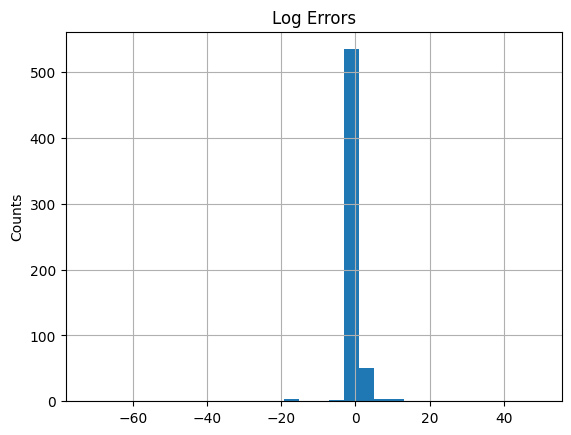

In [18]:
fig, ax = plt.subplots()
ax.hist(df["log_flux_err"],bins=30)
ax.set_title("Log Errors")
ax.set_ylabel("Counts")
ax.grid()

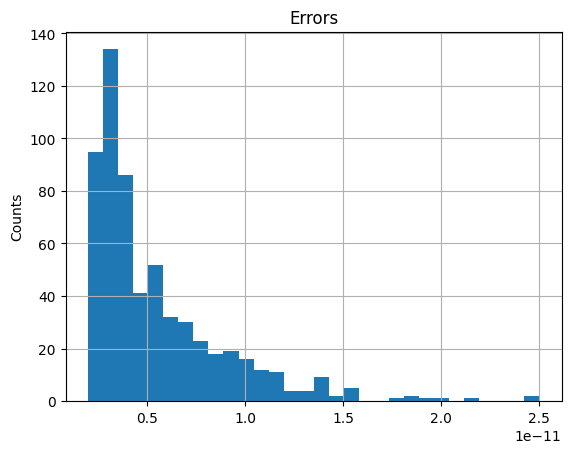

In [15]:
fig, ax = plt.subplots()
ax.hist(df["flux_err_ph_cm2_s"],bins=30)
ax.set_title("Errors")
ax.set_ylabel("Counts")
ax.grid()

<Axes: >

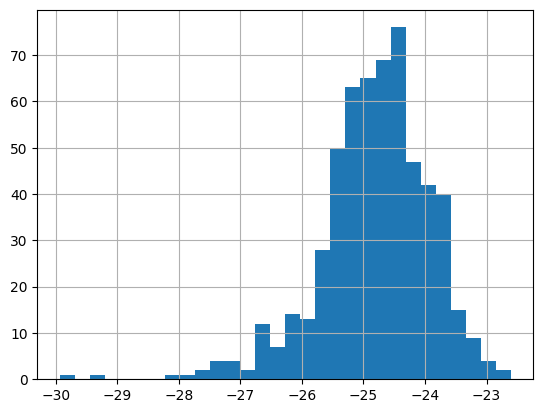

In [10]:
df["log_flux"].hist(bins=30)

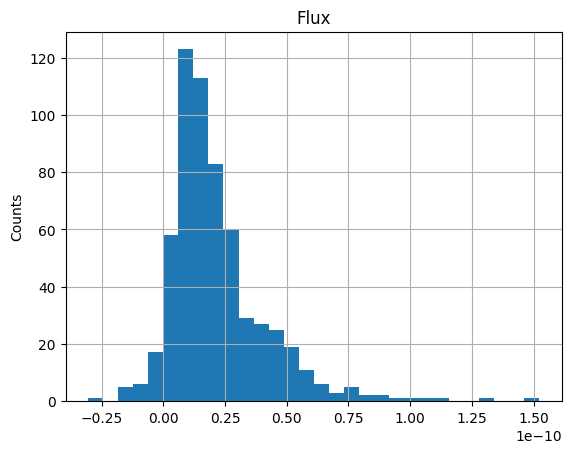

In [14]:
fig, ax = plt.subplots()
ax.hist(df["flux_ph_cm2_s"],bins=30)
ax.set_title("Flux")
ax.set_ylabel("Counts")
ax.grid()

In [2]:
def compute_sta_lta_zscore(df, sta_window, lta_window,
                           min_lta_obs=5, min_sta_obs=2,
                           max_gap_days=60):
    """Compute a robust STA/LTA Z-score on log(flux) for each nightly observation.

    The Z-score measures how many robust standard deviations the short-term
    average (STA) of log-flux lies above or below the long-term median
    background (LTA) of log-flux.  Positive → brightening; negative → dip.

    Key improvements over v1:
      * Operates in log-space (respects lognormal flux distribution).
      * LTA window **excludes** the STA window to prevent flare
        self-contamination.
      * Gap-aware gating: rows with N_STA < ``min_sta_obs`` or where the
        nearest LTA observation is older than ``max_gap_days`` are set to NaN.

    Args:
        df (pd.DataFrame): DataFrame with a DatetimeIndex and columns
            ``log_flux`` and ``log_flux_err``.
        sta_window (str): Short-window size as a pandas offset, e.g. ``'3D'``.
        lta_window (str): Long-window size as a pandas offset, e.g. ``'21D'``.
        min_lta_obs (int): Minimum observations in LTA window. Default 5.
        min_sta_obs (int): Minimum observations in STA window; fewer → NaN.
            Default 2.
        max_gap_days (float): Maximum gap (days) between the current observation
            and the most recent prior observation inside the LTA-only window.
            Exceeding this → NaN.  Default 60.

    Returns:
        pd.DataFrame: Copy of ``df`` with additional columns including
            ``Z_score``, ``N_STA``, ``N_LTA_only``, and quality flag
            ``Z_valid``.
    """
    out = df.copy()
    lf  = out["log_flux"]
    le  = out["log_flux_err"]

    # ── STA statistics ───────────────────────────────────────────────────
    out["N_STA"]    = lf.rolling(sta_window, min_periods=1).count()
    out["STA_mean"] = lf.rolling(sta_window, min_periods=1).mean()

    # Measurement uncertainty on the STA mean (in log-space):
    # σ(mean) = sqrt( mean(σ_i²) / N )
    out["sigma_meas"] = np.sqrt(
        (le ** 2).rolling(sta_window, min_periods=1).mean() / out["N_STA"]
    )

    # ── LTA statistics — EXCLUDING the STA window (Fix 2) ───────────────
    # Strategy: compute full-LTA rolling stats, compute STA rolling stats,
    # then algebraically subtract the STA contribution.
    #
    # For the median (robust) we cannot do simple subtraction, so instead we
    # use a custom apply that only looks at [t - LTA, t - STA).
    sta_days = int(sta_window.replace("D", ""))
    lta_days = int(lta_window.replace("D", ""))

    # Pre-compute arrays for the custom rolling
    dates = out.index
    lf_vals = lf.values
    le_vals = le.values

    n_lta_only      = np.full(len(out), np.nan)
    lta_median_arr  = np.full(len(out), np.nan)
    sigma_intr_arr  = np.full(len(out), np.nan)
    gap_days_arr    = np.full(len(out), np.nan)

    for i in range(len(out)):
        t_i = dates[i]
        # LTA-only window: [t - lta_days, t - sta_days)
        t_lta_start = t_i - pd.Timedelta(days=lta_days)
        t_sta_start = t_i - pd.Timedelta(days=sta_days)

        mask = (dates >= t_lta_start) & (dates < t_sta_start)
        vals = lf_vals[mask]

        if len(vals) < min_lta_obs:
            continue

        n_lta_only[i] = len(vals)
        med = np.median(vals)
        lta_median_arr[i] = med

        # MAD → σ (1.4826 factor; robust even for non-Gaussian)
        mad = np.median(np.abs(vals - med))
        sigma_intr_arr[i] = 1.4826 * mad

        # Gap: distance from t_i to the newest point in the LTA-only window
        lta_dates = dates[mask]
        gap_days_arr[i] = (t_i - lta_dates[-1]).total_seconds() / 86400.0

    out["N_LTA_only"]      = n_lta_only
    out["LTA_median"]      = lta_median_arr
    out["sigma_intrinsic"] = sigma_intr_arr
    out["gap_to_LTA_days"] = gap_days_arr

    # ── Total denominator ────────────────────────────────────────────────
    out["sigma_total"] = np.sqrt(out["sigma_meas"] ** 2
                                 + out["sigma_intrinsic"] ** 2)

    # ── Z-score ──────────────────────────────────────────────────────────
    out["Z_score"] = (out["STA_mean"] - out["LTA_median"]) / (
        out["sigma_total"] + 1e-30
    )

    # ── Fix 4: Gap-aware gating ──────────────────────────────────────────
    stale_lta = out["gap_to_LTA_days"] > max_gap_days
    sparse_sta = out["N_STA"] < min_sta_obs
    out["Z_valid"] = ~(stale_lta | sparse_sta) & out["Z_score"].notna()
    out.loc[~out["Z_valid"], "Z_score"] = np.nan

    # ── Also keep linear-space STA/LTA for plotting ──────────────────────
    out["STA_mean_flux"] = out["flux_ph_cm2_s"].rolling(
        sta_window, min_periods=1
    ).mean()
    out["LTA_median_flux"] = np.exp(out["LTA_median"])

    return out


In [3]:
# ── Filter bank ──────────────────────────────────────────────────────────────
SCALES = [
    ("1D",  "10D",  "Fast   (1d / 10d)"),
    ("3D",  "21D",  "Medium (3d / 21d)"),
    ("7D",  "42D",  "Slow   (7d / 42d)"),
]

# ── Quiescent period for empirical threshold calibration ─────────────────────
QUIESCENT_START = "2015-01-01"
QUIESCENT_END   = "2016-07-01"
QUANTILE        = 0.995   # per-scale upper quantile → empirical threshold

results    = {}
thresholds = {}

for sta_w, lta_w, label in SCALES:
    res = compute_sta_lta_zscore(df, sta_w, lta_w)
    results[label] = res

    # Empirical threshold from quiescent Z-distribution (Fix 3)
    mask_q = (res.index >= QUIESCENT_START) & (res.index <= QUIESCENT_END)
    z_q = res.loc[mask_q, "Z_score"].dropna()
    thr = z_q.quantile(QUANTILE)
    # Symmetric: use |Z| for dip threshold
    thresholds[label] = round(thr, 2)

    n_valid  = res["Z_valid"].sum()
    n_bright = (res["Z_score"] >=  thr).sum()
    n_dip    = (res["Z_score"] <= -thr).sum()
    n_gated  = (~res["Z_valid"]).sum()
    print(f"{label:25s}  threshold={thr:5.2f}σ  "
          f"bright={n_bright:3d}  dips={n_dip:3d}  "
          f"gated_out={n_gated:3d}/{len(res)}")

print(f"\nQuiescent period: {QUIESCENT_START} → {QUIESCENT_END}")
print(f"Quantile used: {QUANTILE}")


Fast   (1d / 10d)          threshold= 3.96σ  bright=  3  dips=  2  gated_out=451/601
Medium (3d / 21d)          threshold= 4.51σ  bright=  1  dips=  2  gated_out=284/601
Slow   (7d / 42d)          threshold= 2.30σ  bright= 11  dips=  8  gated_out=301/601

Quiescent period: 2015-01-01 → 2016-07-01
Quantile used: 0.995


In [4]:
# ── Calibration diagnostics ───────────────────────────────────────────────────
print(f"Quiescent period: {QUIESCENT_START} → {QUIESCENT_END}")
print(f"Quantile: {QUANTILE} (empirical per-scale, no Gaussian assumption)\n")
print(f"{'Scale':25s}  {'Threshold (σ)':>14s}  {'N_quiescent':>13s}  "
      f"{'p99.7':>8s}  {'p99.5':>8s}  {'p99.0':>8s}")
print("-" * 80)
for sta_w, lta_w, label in SCALES:
    res  = results[label]
    mask = (res.index >= QUIESCENT_START) & (res.index <= QUIESCENT_END)
    z_q  = res.loc[mask, "Z_score"].dropna()
    print(f"{label:25s}  {thresholds[label]:>14.2f}  {len(z_q):>13d}  "
          f"{z_q.quantile(0.997):>8.2f}  {z_q.quantile(0.995):>8.2f}  "
          f"{z_q.quantile(0.990):>8.2f}")


Quiescent period: 2015-01-01 → 2016-07-01
Quantile: 0.995 (empirical per-scale, no Gaussian assumption)

Scale                       Threshold (σ)    N_quiescent     p99.7     p99.5     p99.0
--------------------------------------------------------------------------------
Fast   (1d / 10d)                    3.96             55      4.19      3.96      3.41
Medium (3d / 21d)                    4.51            102      4.53      4.51      4.45
Slow   (7d / 42d)                    2.30             78      2.33      2.30      2.24


In [5]:
import numpy
import astropy
print(f"NumPy version: {numpy.__version__}")
print(f"Astropy version: {astropy.__version__}")


NumPy version: 2.4.4
Astropy version: 7.2.0


/var/folders/74/0zssb6h97glb_0klc2951pqc0000gn/T/ipykernel_13796/925035613.py:51: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(start, end, color=col, alpha=0.14,
/var/folders/74/0zssb6h97glb_0klc2951pqc0000gn/T/ipykernel_13796/925035613.py:54: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(start, end, color=col, alpha=0.10,


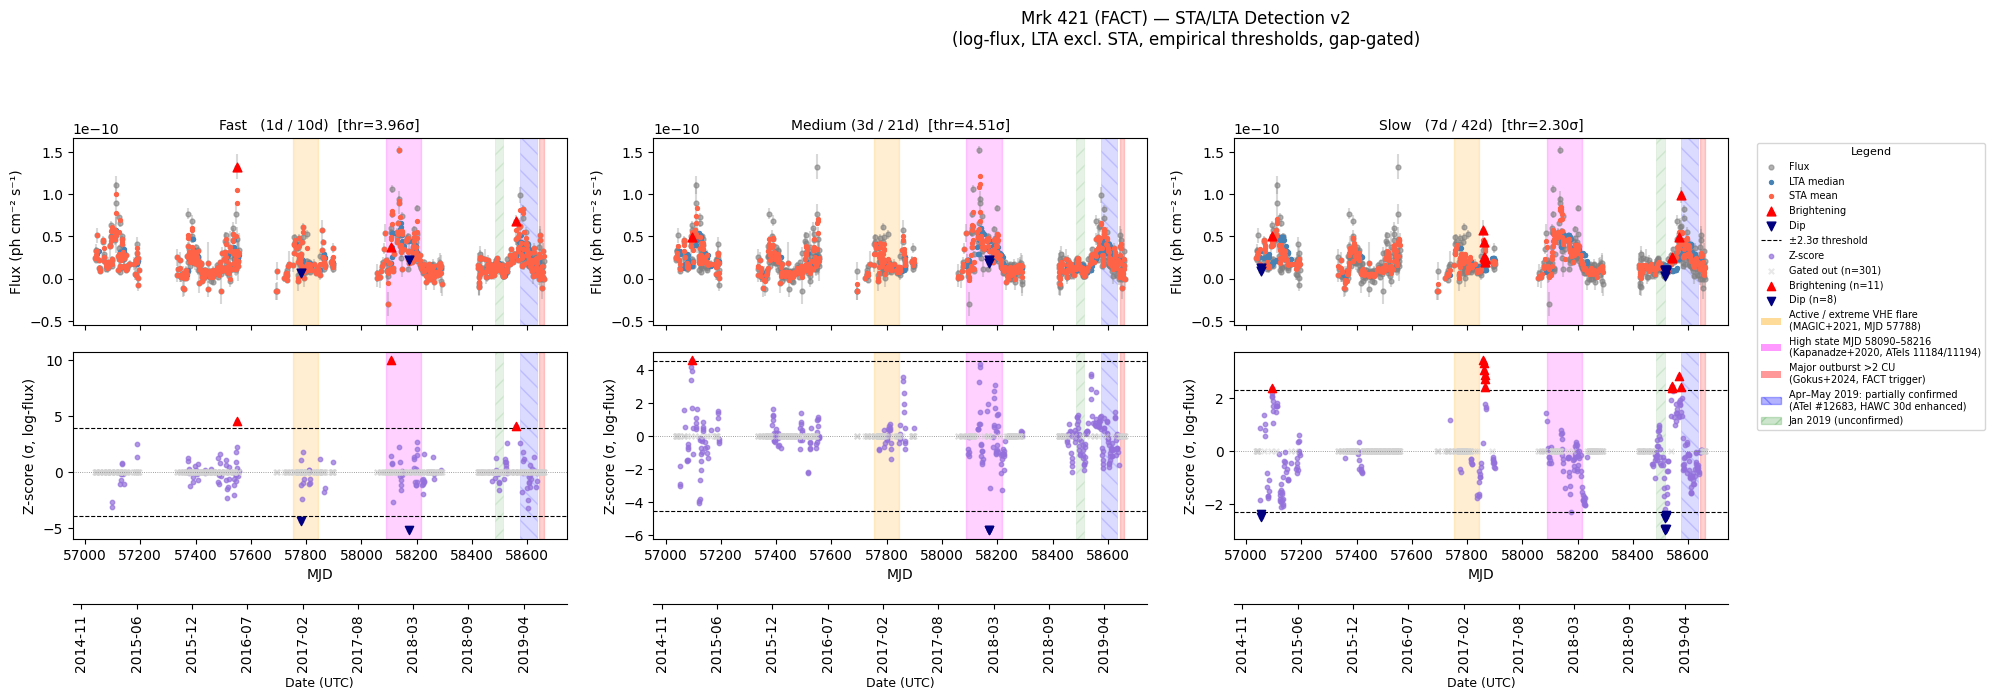


Scale                       Thr (σ)    Bright    Dips    Gated    Valid
--------------------------------------------------------------------
Fast   (1d / 10d)              3.96         3       2      451      150
Medium (3d / 21d)              4.51         1       2      284      317
Slow   (7d / 42d)              2.30        11       8      301      300


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# ── Shaded regions: confirmed vs partially confirmed vs unconfirmed ──────────
# Fix 6: Apr-May 2019 upgraded to partially confirmed (ATel #12683, HAWC)
# Fix 7: Dec 2017 window extended to Apr 2018 consistently
t_regions_confirmed = [
    (Time("2017-01-01").mjd, Time("2017-03-31").mjd,
     "orange", "Active / extreme VHE flare\n(MAGIC+2021, MJD 57788)"),
    (Time("2017-12-01").mjd, Time("2018-04-08").mjd,
     "magenta", "High state MJD 58090–58216\n(Kapanadze+2020, ATels 11184/11194)"),
    (Time("2019-06-09").mjd, Time("2019-06-25").mjd,
     "red", "Major outburst >2 CU\n(Gokus+2024, FACT trigger)"),
]

t_regions_partial = [
    (Time("2019-04-01").mjd, Time("2019-05-31").mjd,
     "blue", "Apr–May 2019: partially confirmed\n(ATel #12683, HAWC 30d enhanced)"),
]

t_regions_unconfirmed = [
    (Time("2019-01-01").mjd, Time("2019-01-31").mjd,
     "green", "Jan 2019 (unconfirmed)"),
]

fig, axes = plt.subplots(
    nrows=2, ncols=len(SCALES),
    figsize=(6 * len(SCALES) + 6, 8),
    sharex=True
)

if len(SCALES) == 1:
    axes = axes.reshape(2, 1)

for col_idx, (sta_w, lta_w, label) in enumerate(SCALES):
    res    = results[label]
    thr    = thresholds[label]
    bright = res[res["Z_score"] >=  thr].copy()
    dip    = res[res["Z_score"] <= -thr].copy()

    ax_lc = axes[0, col_idx]
    ax_z  = axes[1, col_idx]

    for ax in [ax_lc, ax_z]:
        for start, end, col, _ in t_regions_confirmed:
            ax.axvspan(start, end, color=col, alpha=0.18, zorder=0)
        for start, end, col, _ in t_regions_partial:
            ax.axvspan(start, end, color=col, alpha=0.14,
                       hatch="\\\\", edgecolor=col, linewidth=0.5, zorder=0)
        for start, end, col, _ in t_regions_unconfirmed:
            ax.axvspan(start, end, color=col, alpha=0.10,
                       hatch="//", edgecolor=col, linewidth=0.5, zorder=0)

    # ── Light curve panel ─────────────────────────────────────────────────
    ax_lc.errorbar(res["MJD"], res["flux_ph_cm2_s"],
                   yerr=res["flux_err_ph_cm2_s"],
                   fmt="none", ecolor="gray", alpha=0.3, zorder=1)
    ax_lc.scatter(res["MJD"], res["flux_ph_cm2_s"],
                  color="gray", alpha=0.6, s=12, label="Flux", zorder=2)
    ax_lc.scatter(res["MJD"], res["LTA_median_flux"],
                  color="steelblue", s=8, label="LTA median", zorder=3)
    ax_lc.scatter(res["MJD"], res["STA_mean_flux"],
                  color="tomato", s=8, label="STA mean", zorder=4)
    if not bright.empty:
        ax_lc.scatter(bright["MJD"], bright["flux_ph_cm2_s"],
                      color="red", s=40, marker="^", zorder=5, label="Brightening")
    if not dip.empty:
        ax_lc.scatter(dip["MJD"], dip["flux_ph_cm2_s"],
                      color="navy", s=40, marker="v", zorder=5, label="Dip")
    ax_lc.set_ylabel("Flux (ph cm⁻² s⁻¹)")
    ax_lc.set_title(f"{label}  [thr={thr:.2f}σ]", fontsize=10)

    # ── Z-score panel ─────────────────────────────────────────────────────
    ax_z.axhline( thr, color="black", linestyle="--", linewidth=0.8,
                 label=f"±{thr:.1f}σ threshold")
    ax_z.axhline(-thr, color="black", linestyle="--", linewidth=0.8)
    ax_z.axhline(0, color="gray", linestyle=":", linewidth=0.6)

    valid = res[res["Z_valid"]]
    gated = res[~res["Z_valid"]]
    ax_z.scatter(valid["MJD"], valid["Z_score"],
                 color="mediumpurple", s=10, alpha=0.7, label="Z-score")
    # Show gated-out points as faint ×
    if not gated.empty:
        ax_z.scatter(gated["MJD"], [0]*len(gated),
                     color="lightgray", s=15, marker="x", alpha=0.5,
                     label=f"Gated out (n={len(gated)})")

    if not bright.empty:
        ax_z.scatter(bright["MJD"], bright["Z_score"],
                     color="red", s=35, marker="^", zorder=5,
                     label=f"Brightening (n={len(bright)})")
    if not dip.empty:
        ax_z.scatter(dip["MJD"], dip["Z_score"],
                     color="navy", s=35, marker="v", zorder=5,
                     label=f"Dip (n={len(dip)})")
    ax_z.set_xlabel("MJD")
    ax_z.set_ylabel("Z-score (σ, log-flux)")

    # ── Secondary date axis ───────────────────────────────────────────────
    def mjd_to_date(mjd_val):
        """Convert MJD array to matplotlib date numbers."""
        mjd_val = np.asanyarray(mjd_val)
        if mjd_val.size == 0:
            return mjd_val
        return mdates.date2num(Time(mjd_val, format="mjd").to_datetime())

    def date_to_mjd(date_num):
        """Convert matplotlib date numbers to MJD."""
        date_num = np.asanyarray(date_num)
        if date_num.size == 0:
            return date_num
        return Time(mdates.num2date(date_num)).mjd

    secax = ax_z.secondary_xaxis(
        -0.35, functions=(mjd_to_date, date_to_mjd)
    )
    secax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    secax.set_xlabel("Date (UTC)", fontsize=9)
    plt.setp(secax.get_xticklabels(), rotation=90, ha="center")

# ── Global legend ─────────────────────────────────────────────────────────────
handles, labels_h = axes[0, -1].get_legend_handles_labels()
z_h, z_l = axes[1, -1].get_legend_handles_labels()
combined = dict(zip(labels_h + z_l, handles + z_h))

for start, end, col, lab in t_regions_confirmed:
    combined[lab] = Patch(facecolor=col, alpha=0.4, label=lab)
for start, end, col, lab in t_regions_partial:
    combined[lab] = Patch(facecolor=col, alpha=0.3,
                          hatch="\\\\", edgecolor=col, label=lab)
for start, end, col, lab in t_regions_unconfirmed:
    combined[lab] = Patch(facecolor=col, alpha=0.2,
                          hatch="//", edgecolor=col, label=lab)

axes[0, -1].legend(
    combined.values(), combined.keys(),
    loc="upper left", bbox_to_anchor=(1.05, 1),
    fontsize=7, frameon=True, title="Legend", title_fontsize=8
)

plt.suptitle(
    "Mrk 421 (FACT) — STA/LTA Detection v2\n"
    "(log-flux, LTA excl. STA, empirical thresholds, gap-gated)",
    fontsize=12, y=0.99
)
plt.tight_layout(rect=(0, 0.08, 0.84, 0.94))
plt.show()

# ── Detection summary ─────────────────────────────────────────────────────────
print(f"\n{'Scale':25s}  {'Thr (σ)':>8s}  {'Bright':>8s}  {'Dips':>6s}  "
      f"{'Gated':>7s}  {'Valid':>7s}")
print("-" * 68)
for sta_w, lta_w, label in SCALES:
    res = results[label]
    thr = thresholds[label]
    b   = (res["Z_score"] >=  thr).sum()
    d   = (res["Z_score"] <= -thr).sum()
    g   = (~res["Z_valid"]).sum()
    v   = res["Z_valid"].sum()
    print(f"{label:25s}  {thr:>8.2f}  {b:>8d}  {d:>6d}  {g:>7d}  {v:>7d}")


## Activity Table (v2 — audited)

| Date(s)                    | Activity Level                        | Instruments                  | Notes                                                                                      | Status                |
|:---------------------------|:--------------------------------------|:-----------------------------|:-------------------------------------------------------------------------------------------|:----------------------|
| Jan – Mar 2017             | Active period incl. extreme VHE flare | FACT, MAGIC, NuSTAR          | MJD 57788 (Feb 4): factor-10 TeV increase, orphan-like, two-zone leptonic model required (MAGIC+2021) | Confirmed             |
| Dec 2017 – Apr 2018        | High state / exceptional TeV flare    | Swift XRT/BAT, FACT, HAWC, TACTIC | MJD 58090–58216; ATels #11184 (FACT exceptional flare), #11194 (HAWC month-long peak), #11195 (Swift/BAT correlated hard X-ray); Kapanadze+2020 | Confirmed             |
| Jan 2019                   | Unknown                               | —                            | No ATel or peer-reviewed reference found; may be post-seasonal-gap artifact. Needs MWL cross-check | Unconfirmed           |
| Apr – May 2019             | Enhanced TeV activity (~30 d)         | HAWC, (FACT)                 | ATel #12683 (HAWC, 23 Apr 2019): enhanced activity for >30 days. Overlaps STA/LTA detection window | Partially confirmed   |
| Jun 9–25, 2019             | Major outburst                        | FACT (trigger), XMM-Newton   | >2 CU on Jun 9; brightest XMM-Newton state ever recorded; Gokus+2024 (MNRAS 529, 1450)    | Confirmed             |

## Changelog v1 → v2

| # | Fix | Rationale |
|---|-----|-----------|
| 1 | Pipeline on log(flux) | Flux PDF is lognormal (Acciari+2021 MNRAS 504, Chakraborty 2020). Log-transform symmetrises the distribution, making MAD→σ conversion and Z-score tails well-behaved. |
| 2 | LTA excludes STA window | Prevents the flare being detected from inflating its own background estimate. With FACT cadence (~5–10 pts in a 21-day window), a single bright night can exceed the median breakdown point. |
| 3 | Per-scale empirical thresholds | The 1d/10d fast scale had p99.7 = 4.89σ vs Gaussian 3.0σ — heavy tails even in quiescence. Using quantile 99.5 of the quiescent Z-distribution per scale removes the normality assumption entirely. |
| 4 | Gap-aware gating | After seasonal gaps, the first observations have N_STA=1 and stale LTA. These are now masked (N_STA < 2 or gap > 60d), preventing spurious triggers at gap boundaries. |
| 5 | Apr–May 2019 → Partially confirmed | ATel #12683 (HAWC, 23 Apr 2019) independently reports >30 days enhanced TeV activity coinciding with the STA/LTA detection. |
| 6 | Dec 2017 window → Apr 2018 | Code and table now consistently use Dec 2017–Apr 2018, matching Kapanadze+2020 (MJD 58090–58216) and ATels #11184/#11194/#11195. |